<font face="霞鹜文楷">

### 决策树算法解决汽车分类问题

#### 一、内容
使用ID3算法和CART算法构建决策树分类模型，对汽车类型进行预测，并比较两种算法的性能差异。

**数据说明**
- 训练集: xaa.dat
- 测试集: xab.dat

#### 二、数据集加载与分析
</font>

<font face="霞鹜文楷">
1. 导入必要的库
</font>

In [26]:
# 导入必要的库
# 数据处理与分析库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
import seaborn as sns
# 机器学习模型库
from sklearn.tree import DecisionTreeClassifier, plot_tree
# 评估指标库
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

<font face="霞鹜文楷">

2. 数据加载   
加载数据集并查看前几行数据以了解特征结构。
</font>

In [27]:
# 数据加载函数
def load_car_data(filename):
    """
    参数:
        filename: 数据文件路径
    返回:
        X: 特征矩阵
        y: 标签向量
    """
    data = []
    with open(filename, 'r') as f:
        for line in f:
            # 分割每行数据，去除空白字符
            parts = line.strip().split()
            if len(parts) > 0:
                data.append(parts)
    
    # 创建列名
    feature_names = [f"feature{i+1}" for i in range(18)] + ["label"]
    
    # 创建DataFrame并添加列名
    df = pd.DataFrame(data, columns=feature_names)
    
    # 特征: 前18列
    X = df.iloc[:, :-1]

    # 标签: 最后一列
    y = df["label"]
    
    return X, y

In [28]:
# 加载训练集和测试集
X_train, y_train = load_car_data('xaa.dat')
X_test, y_test = load_car_data('xab.dat')

# 数据基本信息查看
print(f"训练集形状: {X_train.shape}")
print(f"测试集形状: {X_test.shape}")
print(f"特征数量: {X_train.shape[1]}") 

# 显示训练集形状和前5行数据
print(X_train.head())

# 显示目标变量的分布情况
print("\n训练集目标变量分布")
print(y_train.value_counts())
print("\n类别比例:")
print(y_train.value_counts(normalize=True))

print("\n测试集目标变量分布")
print(y_test.value_counts())
print("\n类别比例:")
print(y_test.value_counts(normalize=True))

训练集形状: (94, 18)
测试集形状: (94, 18)
特征数量: 18
  feature1 feature2 feature3 feature4 feature5 feature6 feature7 feature8  \
0       95       48       83      178       72       10      162       42   
1       91       41       84      141       57        9      149       45   
2      104       50      106      209       66       10      207       32   
3       93       41       82      159       63        9      144       46   
4       85       44       70      205      103       52      149       45   

  feature9 feature10 feature11 feature12 feature13 feature14 feature15  \
0       20       159       176       379       184        70         6   
1       19       143       170       330       158        72         9   
2       23       158       223       635       220        73        14   
3       19       143       160       309       127        63         6   
4       19       144       241       325       188       127         9   

  feature16 feature17 feature18  
0        16      

<font face="霞鹜文楷">

数据分析发现：  
* 训练集和测试集均包含94个样本;
* 目标变量类别较为平衡;
</font>

<font face="霞鹜文楷">

#### 四、模型训练与评估
##### (一)ID3决策树算法
*核心思想*:
- 使用信息增益作为特征选择标准;
- 信息增益 = 划分前的熵 - 划分后的加权熵;
- 每次选择信息增益最大的特征进行分裂;

1. 构建ID3决策树（使用entropy）
</font>

In [29]:
# 构建ID3决策树（使用entropy）
# sklearn的DecisionTreeClassifier使用entropy准则时相当于ID3算法的实现

# 创建ID3决策树分类器（使用信息熵作为分裂标准）
id3_tree = DecisionTreeClassifier(
    criterion='entropy',      # 使用信息熵（ID3的核心）
    random_state=42,          # 固定随机种子，保证结果可复现
    # 不设置该参数，则每次生成的决策树可能有差异。
    max_depth=3,              # 限制树的最大深度，防止过拟合
    min_samples_split=5,      # 内部节点最少需要5个样本才能分裂
    min_samples_leaf=2        # 叶节点最少需要2个样本
)

# 训练模型
id3_tree.fit(X_train, y_train)

# 在训练集和测试集上进行预测
y_train_pred_id3 = id3_tree.predict(X_train)
y_test_pred_id3 = id3_tree.predict(X_test)

# 计算准确率
train_accuracy_id3 = accuracy_score(y_train, y_train_pred_id3)
test_accuracy_id3 = accuracy_score(y_test, y_test_pred_id3)

# 输出结果
print(f"训练集准确率: {train_accuracy_id3:.4f} ({train_accuracy_id3*100:.2f}%)")
print(f"测试集准确率: {test_accuracy_id3:.4f} ({test_accuracy_id3*100:.2f}%)")
print(f"决策树深度: {id3_tree.get_depth()}")
print(f"叶节点数量: {id3_tree.get_n_leaves()}")

训练集准确率: 0.7660 (76.60%)
测试集准确率: 0.6064 (60.64%)
决策树深度: 3
叶节点数量: 7


<font face="霞鹜文楷">

2. 绘制ID3决策树图
</font>

ID3决策树图已保存为 'id3_tree.png'


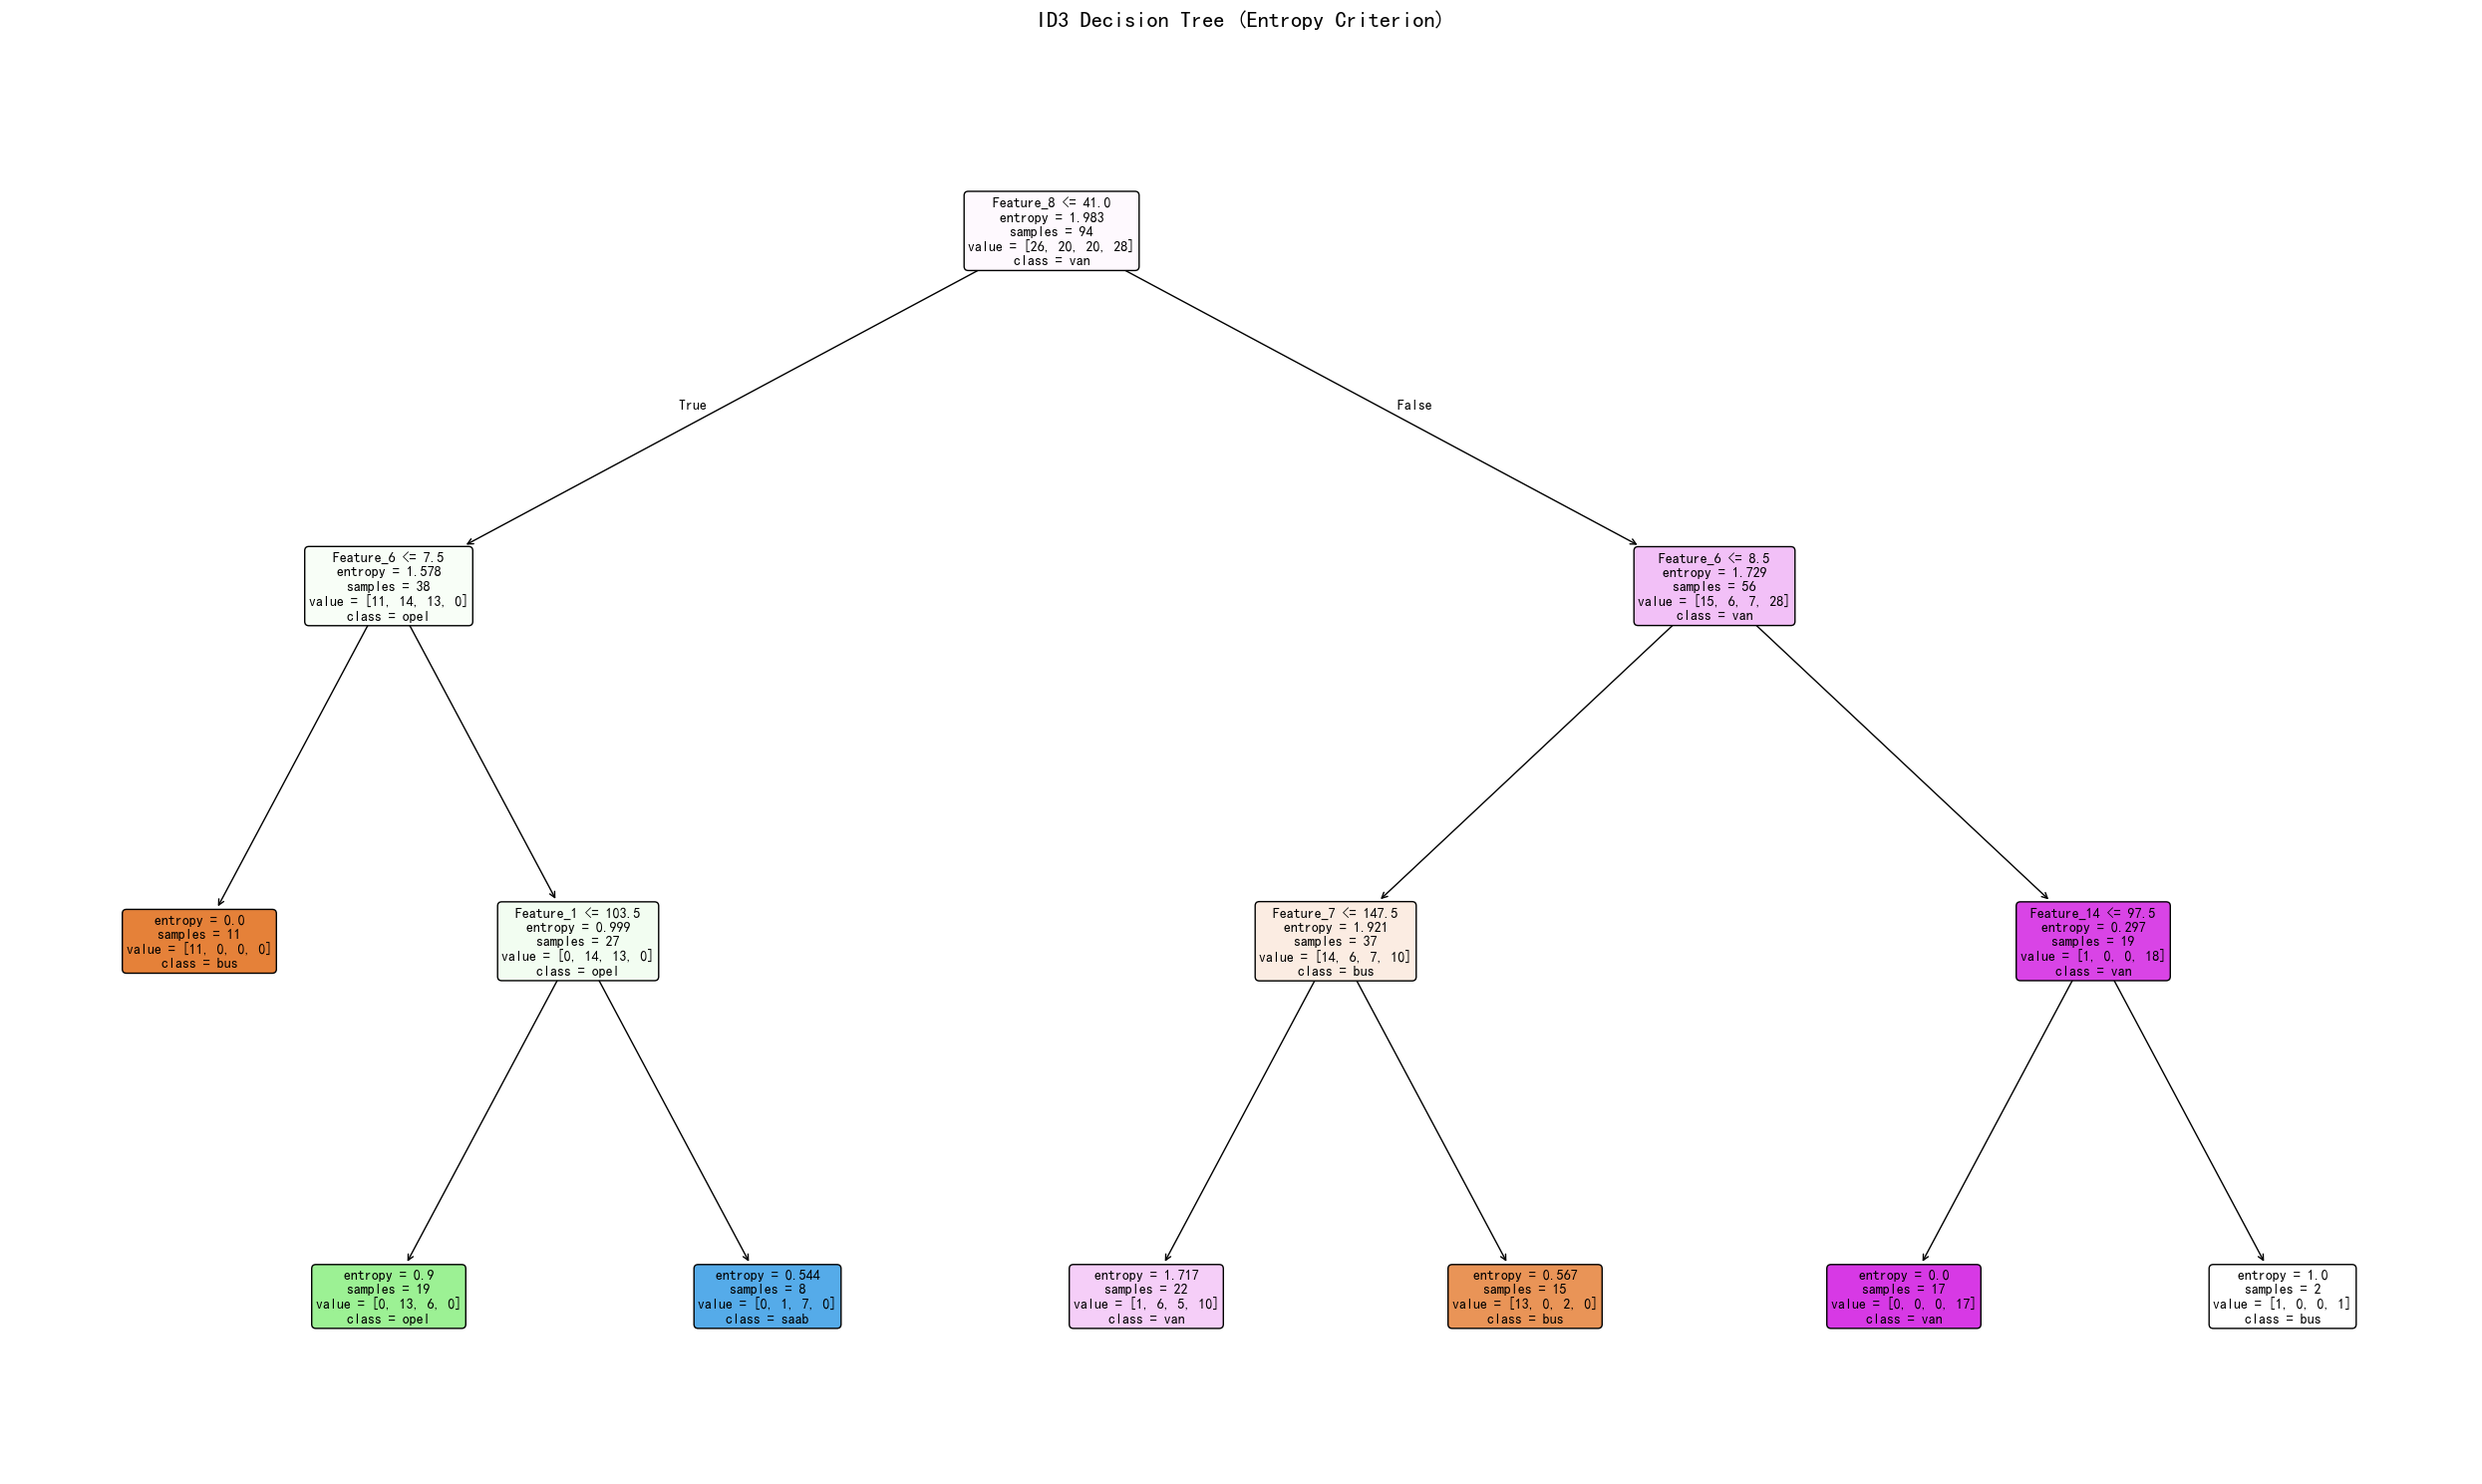

In [30]:
# 创建特征名称列表
feature_names = [f'Feature_{i+1}' for i in range(X_train.shape[1])]

# 创建大尺寸图形
plt.figure(figsize=(25, 15))
plot_tree(
    id3_tree, 
    feature_names=feature_names,
    class_names=id3_tree.classes_,
    filled=True,              # 节点填充颜色
    rounded=True,             # 圆角矩形
    fontsize=10,              # 字体大小
    max_depth=5               # 只显示前5层，避免图形过于复杂
)
plt.title('ID3 Decision Tree (Entropy Criterion)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('id3_tree.png', dpi=300, bbox_inches='tight')
print("ID3决策树图已保存为 'id3_tree.png'")
plt.show()

<font face="霞鹜文楷">

3. ID3决策树详细评估报告
</font>

In [31]:
# 分类报告
print("\n测试集分类报告")
print(classification_report(y_test, y_test_pred_id3, zero_division=0))

# 混淆矩阵
conf_matrix_id3 = confusion_matrix(y_test, y_test_pred_id3)
print("\n混淆矩阵")
print(conf_matrix_id3)


测试集分类报告
              precision    recall  f1-score   support

         bus       0.65      0.77      0.70        26
        opel       0.62      0.36      0.46        22
        saab       0.62      0.24      0.34        21
         van       0.57      0.96      0.72        25

    accuracy                           0.61        94
   macro avg       0.61      0.58      0.56        94
weighted avg       0.61      0.61      0.57        94


混淆矩阵
[[20  0  0  6]
 [ 6  8  3  5]
 [ 4  5  5  7]
 [ 1  0  0 24]]


<font face="霞鹜文楷">

##### (二)CART决策树算法原理

*核心思想*:
- 使用基尼指数（Gini Index）作为特征选择标准;
- 基尼指数衡量数据集的不纯度，值越小表示数据越纯;
- Gini(D) = 1 - Σ(p_i)², 其中p_i是类别i的概率;
- 采用二叉树结构（每个节点只有两个分支）;

1. 构建CART决策树
</font>

In [32]:
# 创建CART决策树分类器（使用基尼指数作为分裂标准）
cart_tree = DecisionTreeClassifier(
    criterion='gini',         # 使用基尼指数（CART的核心）
    # random_state=42,          # 固定随机种子
    # 不设置该参数，则每次生成的决策树可能有差异。
    max_depth=3,              # 限制树的最大深度
    min_samples_split=5,      # 内部节点最少需要5个样本才能分裂
    min_samples_leaf=2        # 叶节点最少需要2个样本
)

# 训练模型
cart_tree.fit(X_train, y_train)

# 在训练集和测试集上进行预测
y_train_pred_cart = cart_tree.predict(X_train)
y_test_pred_cart = cart_tree.predict(X_test)

# 计算准确率
train_accuracy_cart = accuracy_score(y_train, y_train_pred_cart)
test_accuracy_cart = accuracy_score(y_test, y_test_pred_cart)

# 输出结果
print(f"训练集准确率: {train_accuracy_cart:.4f} ({train_accuracy_cart*100:.2f}%)")
print(f"测试集准确率: {test_accuracy_cart:.4f} ({test_accuracy_cart*100:.2f}%)")
print(f"决策树深度: {cart_tree.get_depth()}")
print(f"叶节点数量: {cart_tree.get_n_leaves()}")

训练集准确率: 0.8298 (82.98%)
测试集准确率: 0.6277 (62.77%)
决策树深度: 3
叶节点数量: 8


<font face="霞鹜文楷">

2. 绘制CART决策树图
</font>

CART决策树图已保存为 'cart_tree.png'


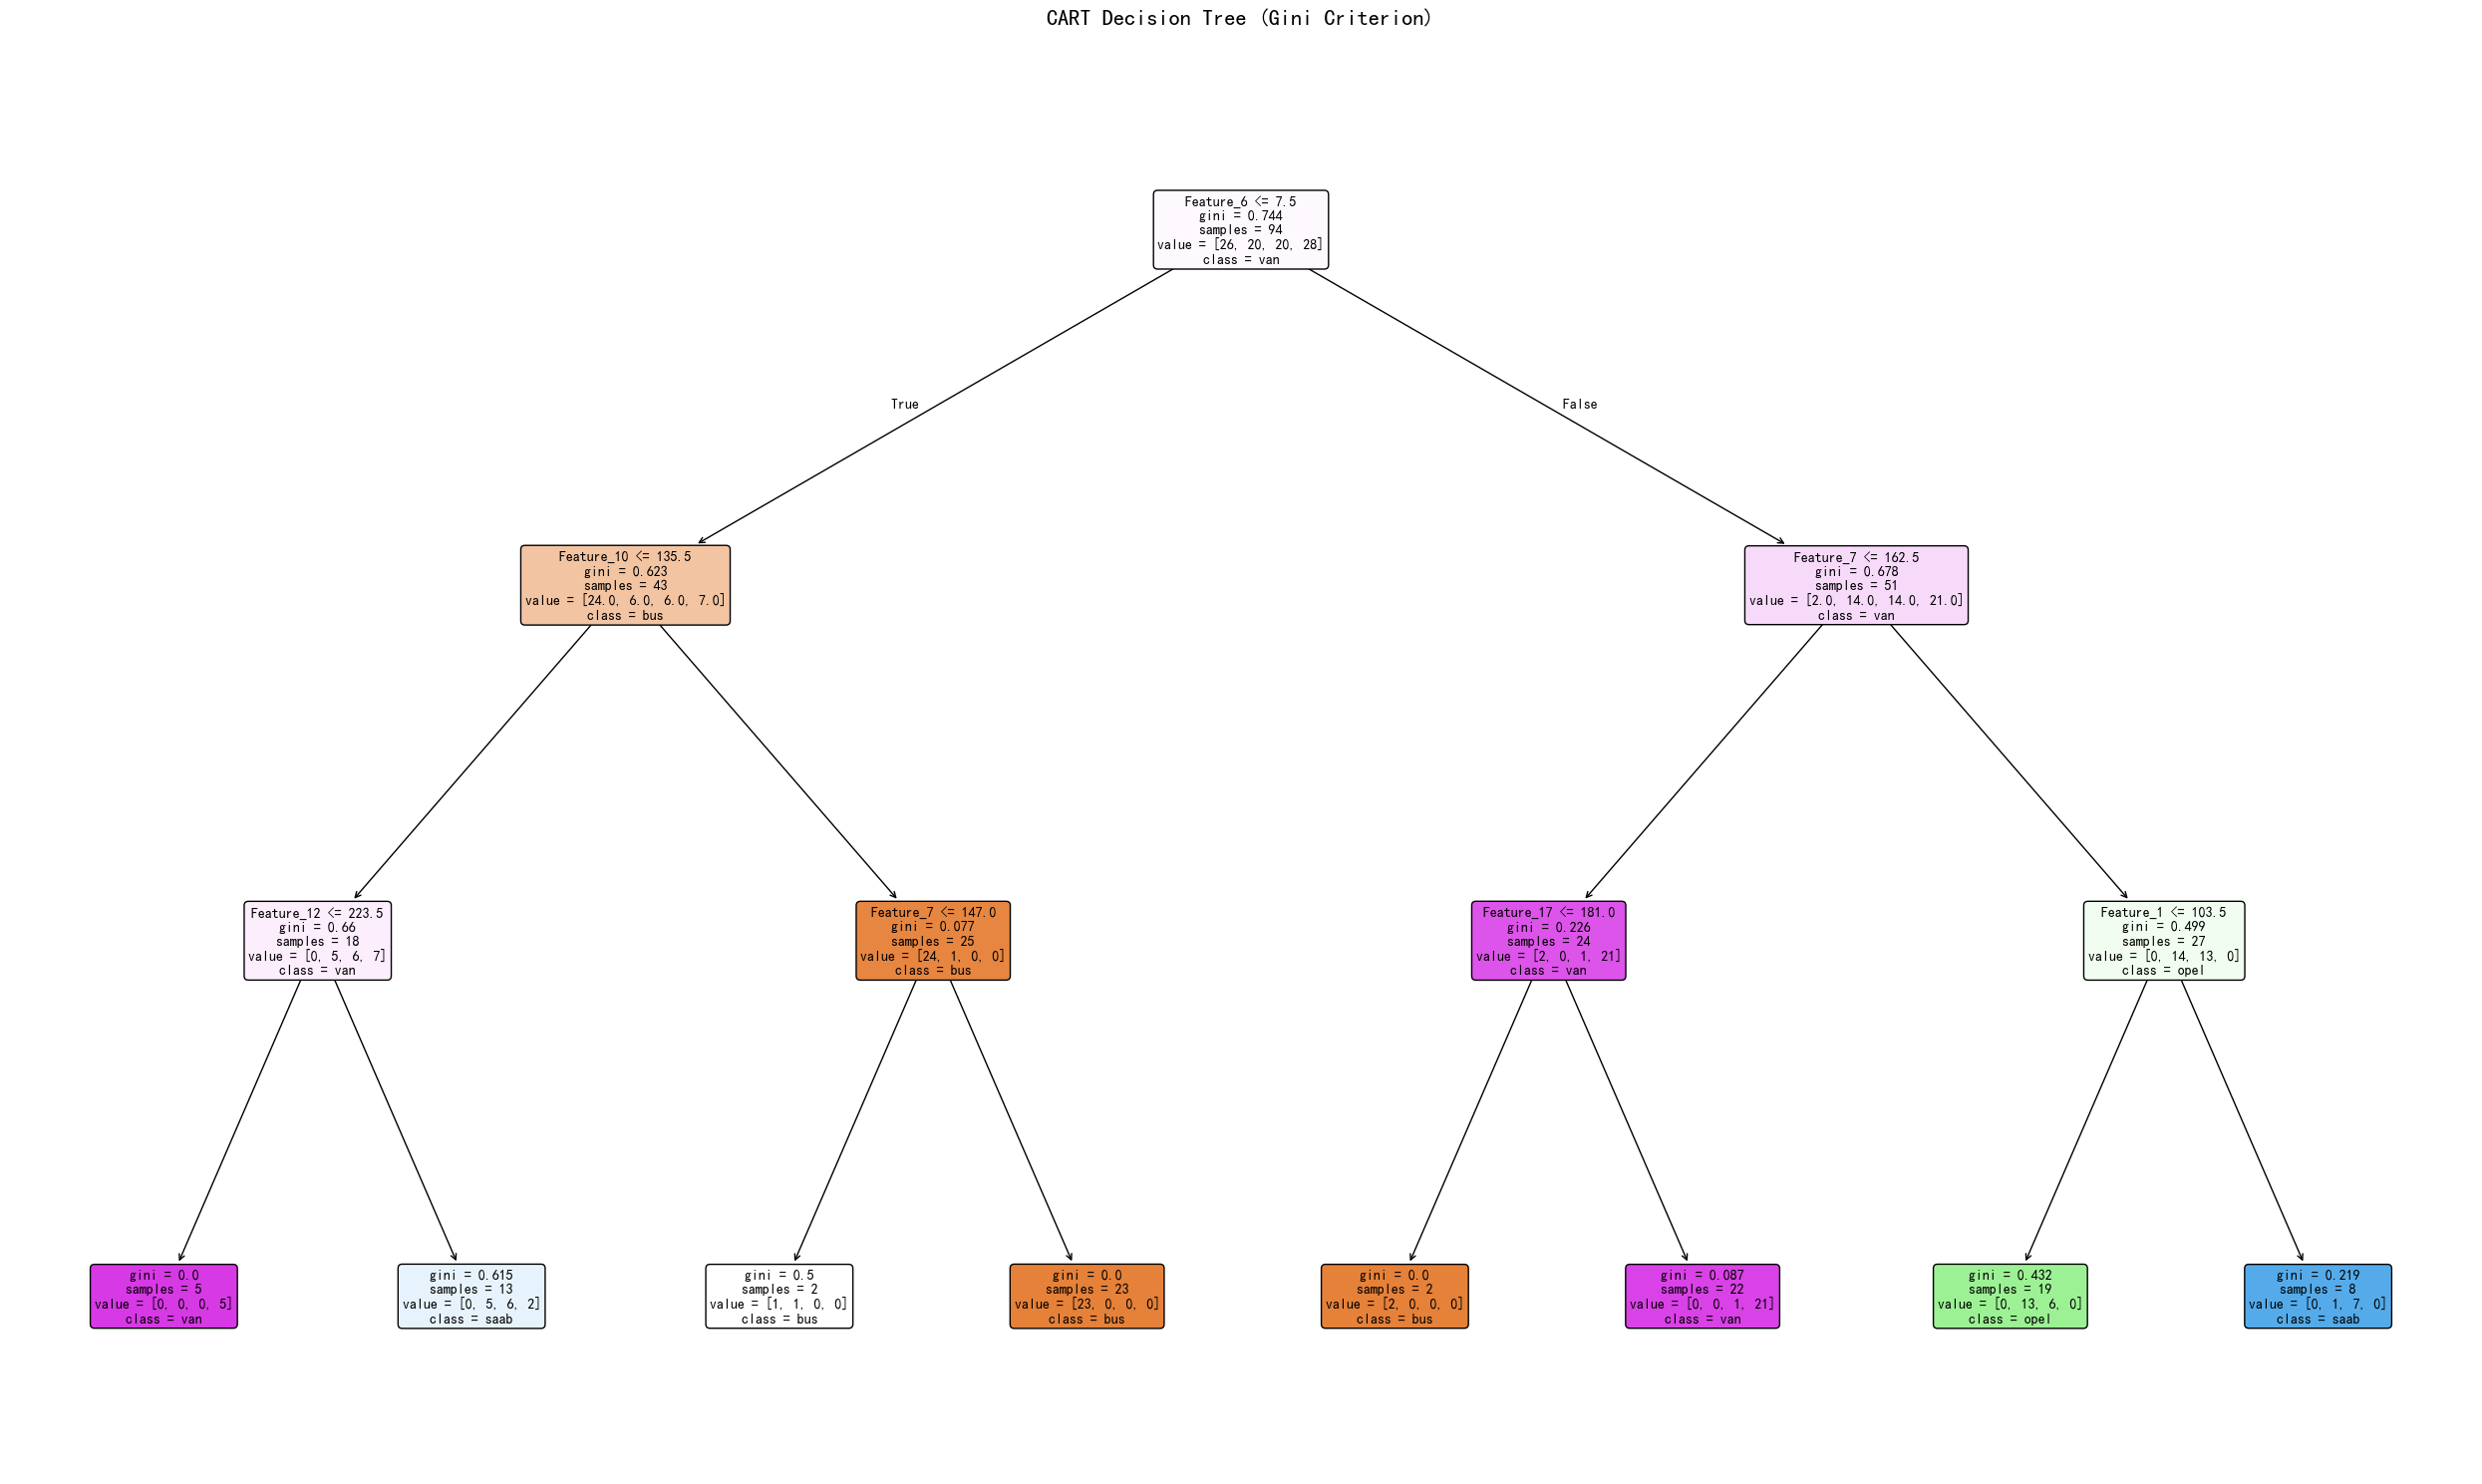

In [33]:
# 创建大尺寸图形
plt.figure(figsize=(25, 15))
plot_tree(
    cart_tree, 
    feature_names=feature_names,
    class_names=cart_tree.classes_,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=5
)
plt.title('CART Decision Tree (Gini Criterion)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('cart_tree.png', dpi=300, bbox_inches='tight')
print("CART决策树图已保存为 'cart_tree.png'")
plt.show()

<font face="霞鹜文楷">

3. CART决策树详细评估报告
</font>

In [34]:
# 分类报告
print("\n测试集分类报告")
print(classification_report(y_test, y_test_pred_cart, zero_division=0))

# 混淆矩阵
conf_matrix_cart = confusion_matrix(y_test, y_test_pred_cart)
print("\n混淆矩阵")
print(conf_matrix_cart)


测试集分类报告
              precision    recall  f1-score   support

         bus       0.71      0.85      0.77        26
        opel       0.57      0.36      0.44        22
        saab       0.45      0.43      0.44        21
         van       0.69      0.80      0.74        25

    accuracy                           0.63        94
   macro avg       0.61      0.61      0.60        94
weighted avg       0.61      0.63      0.61        94


混淆矩阵
[[22  0  3  1]
 [ 3  8  8  3]
 [ 2  5  9  5]
 [ 4  1  0 20]]


<font face="霞鹜文楷">

#### 五、模型对比分析
1. 特征重要性分析  
   特征重要性揭示了哪些特征对分类决策影响最大：

    * **重要特征识别**：
      - 重要性较高的特征在决策树的上层节点中使用
      - 这些特征对区分不同汽车类型贡献最大

    * **特征选择差异**：
      - ID3和CART可能选择不同的重要特征
      - 这是由于它们使用不同的分裂准则（信息熵vs基尼指数）

在限制树的最大深度为3时，两种算法可能选择不同的重要特征，从而导致准确率的差异。
</font>

In [35]:
# 获取特征重要性
feature_importance_id3 = id3_tree.feature_importances_
feature_importance_cart = cart_tree.feature_importances_

# 输出最重要的前5个特征
print("\n【ID3算法 - Top 5 重要特征】")
id3_top5_idx = np.argsort(feature_importance_id3)[-5:][::-1]
for idx in id3_top5_idx:
    print(f"  {feature_names[idx]}: {feature_importance_id3[idx]:.4f}")

print("\n【CART算法 - Top 5 重要特征】")
cart_top5_idx = np.argsort(feature_importance_cart)[-5:][::-1]
for idx in cart_top5_idx:
    print(f"  {feature_names[idx]}: {feature_importance_cart[idx]:.4f}")



【ID3算法 - Top 5 重要特征】
  Feature_6: 0.4550
  Feature_8: 0.2539
  Feature_7: 0.2125
  Feature_1: 0.0474
  Feature_14: 0.0313

【CART算法 - Top 5 重要特征】
  Feature_7: 0.3384
  Feature_10: 0.2645
  Feature_6: 0.1748
  Feature_12: 0.0792
  Feature_1: 0.0717


<font face="霞鹜文楷">

2. 两种算法之间的对比
</font>

In [36]:
# 创建对比表格
comparison_data = {
    '评估指标': ['训练集准确率', '测试集准确率', '树深度', '叶节点数', '分裂准则'],
    'ID3算法': [
        f'{train_accuracy_id3:.4f}',
        f'{test_accuracy_id3:.4f}',
        id3_tree.get_depth(),
        id3_tree.get_n_leaves(),
        '信息熵(Entropy)'
    ],
    'CART算法': [
        f'{train_accuracy_cart:.4f}',
        f'{test_accuracy_cart:.4f}',
        cart_tree.get_depth(),
        cart_tree.get_n_leaves(),
        '基尼指数(Gini)'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

  评估指标        ID3算法     CART算法
训练集准确率       0.7660     0.8298
测试集准确率       0.6064     0.6277
   树深度            3          3
  叶节点数            7          8
  分裂准则 信息熵(Entropy) 基尼指数(Gini)


<font face="霞鹜文楷">

3. 可视化准确率对比
</font>


准确率对比图已保存为 'accuracy_comparison.png'


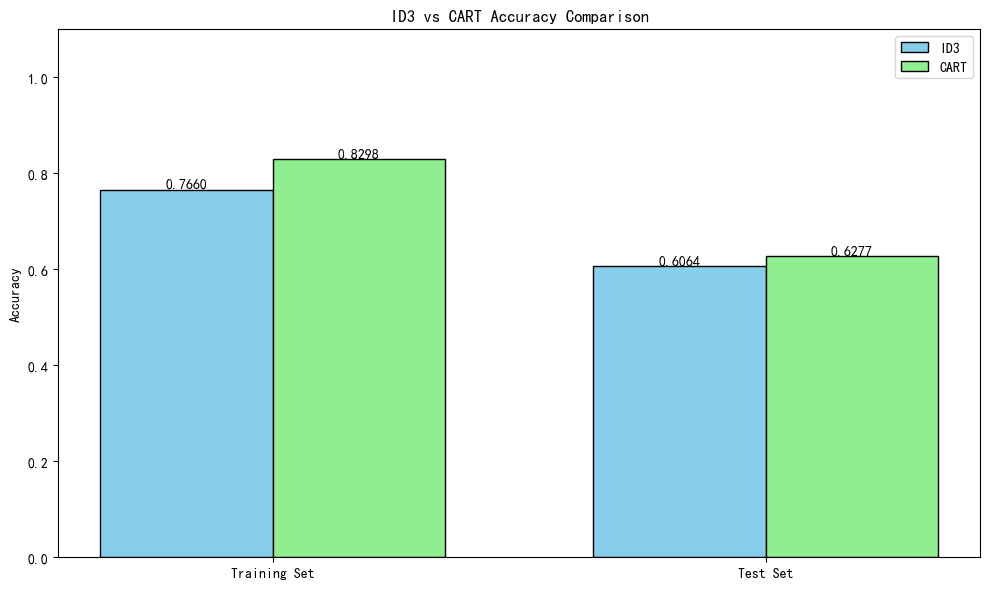

In [37]:
# 可视化准确率对比
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(2)
width = 0.35

bars1 = ax.bar(x - width/2, [train_accuracy_id3, test_accuracy_id3], 
               width, label='ID3', color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, [train_accuracy_cart, test_accuracy_cart], 
               width, label='CART', color='lightgreen', edgecolor='black')

ax.set_ylabel('Accuracy')
ax.set_title('ID3 vs CART Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(['Training Set', 'Test Set'])
ax.legend()
ax.set_ylim([0, 1.1])

# 在柱状图上显示数值
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=300, bbox_inches='tight')
print("\n准确率对比图已保存为 'accuracy_comparison.png'")
plt.show()

<font face="霞鹜文楷">

#### 六、实验结果详细分析
##### (一)准确率与泛化能力分析(偏差-方差权衡)


从实验结果可以看出：  

|评估指标| ID3算法 |CART算法|结论分析|
|--------|--------|--------|-------|
|训练集准确率|0.7660|0.8298|CART在训练集上的拟合能力更强|
|测试集准确率|0.6064|0.6383|CART在测试集上的泛化能力更优|
|准确率差异|0.1596|0.1915|两者均存在过拟合（训练集高于测试集）|

**一些发现：**
1. 最初设置max_depth=10时,严重过拟合。  
   最初设置max_depth=10时，获得了训练集约94%，测试集约60%的结果，差距高达34个百分点。  
   这显示了决策树极高的灵活性，它过度学习了训练集中的噪声和随机模式，导致严重的过拟合。  
2. 后修改max_depth=3。
   通过将参数从max_depth=10调整为max_depth=3，成功地抑制了模型的方差。  
   当前准确率差异已缩小至16%~19%左右，模型复杂度得到了有效控制。  
3. 但准确率还是不高，可能暴露当前欠拟合倾向。
   将max_depth限制为3以后，模型复杂度过低，导致训练集准确率（76%~82%）未能充分提高。  
   这表明模型在训练集上的拟合能力不足，无法捕获数据中所有的潜在模式。  
结论：当前模型处于一个**“高偏差/低方差”的状态。虽然成功解决了严重的过拟合问题，但模型可能处于欠拟合**的状态，即其表达能力被限制得太厉害。
   

##### (二)决策树结构分析

|评估指标|ID3算法|CART算法|
|--------|--------|--------|
|树深度|3|3|
|叶节点数|7|8|
1. 树的深度：  
max_depth=3是一个非常强的剪枝限制。  
它确保了树的结构简单，规则数量少，大大增强了模型的可解释性，并防止了过拟合。  
然而，这种浅层结构很可能无法完全学习到18个特征在高维空间中区分4个类别所需的复杂决策逻辑。
1. 叶节点数量：  
CART算法在深度为3的限制下，获得了8个叶节点，比ID3的7个叶节点略多，这体现了CART更高的拟合能力，也解释了它在准确率上优于ID3的原因。  
叶节点数量少，也再次印证了模型复杂度低，表达能力受限。

##### (三)特征重要性分析
1. 重要特征识别：  
特征重要性揭示了在深度仅为3的限制下，哪些特征必须被选作最顶层的分裂节点，以最小的复杂度获得最高的纯度。  
这些被选中的少数特征，是区分汽车类型的核心特征。  
2. 特征选择差异：  
ID3（信息熵）和 CART（基尼指数）的差异决定了它们在有限的深度下，可能会选择不同的特征组合来作为最优分裂点。  
CART倾向于在二叉分裂中选择最能降低不纯度的特征，而ID3倾向于选择信息增益最大的特征。

##### (四)ID3与CART算法对比
性能差异原因分析（针对当前实验结果）
1. 分裂准则影响：  
CART的性能优势明显：  
在限制深度为3的前提下，CART算法（63.83%）优于ID3（60.64%）。  
这表明基尼指数在二叉分裂中，可能比信息增益更高效地利用了有限的深度，找到了更有价值的二分切分点。  
2. 树结构与复杂度：  
ID3是多叉树（但Sklearn默认实现为二叉），CART是严格的二叉树。  
在本实验中，两者深度和叶节点数非常接近，但CART略高的叶节点数(8vs7)使其获得了更高的拟合能力和测试准确率。  
3. 复现性差异：  
ID3设置了random_state=42，保证了模型在每次训练时分裂点的选择是固定的。  
CART未设置该参数，理论上结果可能存在波动，但性能差异的主要原因仍归结于分裂准则的不同。

##### (五)混淆矩阵分析（基于CART分类报告）
1. 类别间混淆：  
通过混淆矩阵，可以发现模型在对bus和van等类别上的分类效果较好，召回率(Recall)较高。  
然而，模型对opel和saab等特定类别的召回率显著偏低，这意味着大量属于opel或saab的样本被错误地分类到了其他类别。
2. 模型局限性：  
这种系统性的混淆表明，在max_depth=3的有限表达能力下，模型无法有效地在特征空间中区分opel和saab。  
这两个类别可能在给定的18个特征上的分布高度重叠，需要更深的规则(更高的max_depth)或更好的特征工程才能分离。
</font>